# screen_adaptor LUT 可视化

本 Notebook 完成两件事：
1. **场景特征分布散点图**：将每个数据集的图像 DKL 特征（9维）用 PCA 降到 2D，按 cluster 着色，并标注 8 个 prototype 的中心位置。
2. **LUT 颜色变换对比图**：将 RGB 空间下采样到 8×8×8 的色卡，分别应用每个 cluster 的 LUT（16³ 插值），并排展示原始色卡与优化后的色卡，直观对比不同 LUT 的颜色变换差异。

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from PIL import Image
from scipy.interpolate import RegularGridInterpolator

matplotlib.rcParams['figure.dpi'] = 100

# ── 路径配置 ──────────────────────────────────────────────────────────
ROOT = Path.cwd()
_SA_ROOT = ROOT / "screen_adaptor"
_SA_SRC = _SA_ROOT / "src"
sys.path.insert(0, str(_SA_SRC))

# screen_adaptor 场景匹配需要 DKL 特征提取
from screen_adaptor.scene_matcher import (
    load_scene_manifest,
    SceneMatcher,
    load_image_array,
    _extract_feature_fast,
    _sample_window_feature,
    _normalize,
)
from screen_adaptor.colorspace import sRGB2RGB, RGB2DKL

# ── 常量 ────────────────────────────────────────────────────────────────
MANIFEST = _SA_ROOT / "outputs" / "scene_manifest.json"
ASSIGNMENTS = _SA_ROOT / "outputs" / "scene_manifest.assignments.json"
LUT_DIR = _SA_ROOT / "outputs" / "luts"
BASE_LUT = _SA_ROOT / "outputs" / "base_lut.pt"

DATASETS = ["cf", "delta_force", "dfm300", "genshin_impact",
            "jkchess", "miHoYo", "nrc", "sgame0"]

# 每个数据集中抽样的图像数（每个数据集最多取 N 张，控制散点图规模）
MAX_IMAGES_PER_DATASET = 60

print("路径配置完成:")
print(f"  manifest   : {MANIFEST}")
print(f"  assignments: {ASSIGNMENTS}")
print(f"  LUT dir    : {LUT_DIR}")

路径配置完成:
  manifest   : d:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\outputs\scene_manifest.json
  assignments: d:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\outputs\scene_manifest.assignments.json
  LUT dir    : d:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\outputs\luts


## 1. 加载 Manifest 与 Assignments

In [2]:
# 加载 scene manifest（prototypes + feature 标准化参数）
prototypes, feat_mean, feat_std = load_scene_manifest(MANIFEST)
print(f"prototypes: {len(prototypes)}")
for i, p in enumerate(prototypes):
    print(f"  [{i}] {p.name}  lut={p.lut_path}")

# 加载 assignments：图像绝对路径 -> cluster index
with open(ASSIGNMENTS, encoding="utf-8") as f:
    assignments_raw = json.load(f)

# 只保留当前存在的图像路径（旧路径可能已失效）
# 同时注册原始绝对路径与规范化路径，保证 rglob 的相对路径也能匹配
assignments = {}
for path_str, cluster_idx in assignments_raw.items():
    p = Path(path_str)
    if p.exists():
        assignments[path_str] = int(cluster_idx)
        assignments[str(p.resolve())] = int(cluster_idx)

print(f"\nassignments 有效条目: {len(assignments)} / {len(assignments_raw)}")

# 统计每个 dataset 的样本量
from collections import Counter
assign_cluster = Counter(assignments.values())
print("各 cluster 图像数:", dict(sorted(assign_cluster.items())))

prototypes: 8
  [0] cluster_0  lut=D:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\clusters\cluster_0_lut.pt
  [1] cluster_1  lut=D:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\clusters\cluster_1_lut.pt
  [2] cluster_2  lut=D:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\clusters\cluster_2_lut.pt
  [3] cluster_3  lut=D:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\clusters\cluster_3_lut.pt
  [4] cluster_4  lut=D:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\clusters\cluster_4_lut.pt
  [5] cluster_5  lut=D:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\clusters\cluster_5_lut.pt
  [6] cluster_6  lut=D:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\clusters\cluster_6_lut.pt
  [7] cluster_7  lut=D:\workspace\master\3DGS\Vulkan\display_project\screen_adaptor\clusters\cluster_7_lut.pt

assignments 有效条目: 4998 / 4998
各 cluster 图像数: {0: 1859, 1: 508, 2: 436, 3: 239, 4: 663, 5: 345, 6: 338, 7:

## 2. 提取所有图像的 9 维 DKL 特征

In [3]:
# 对每个数据集抽样固定数量的图像，提取 9 维 DKL 特征
image_paths = []
image_features = []
image_clusters = []
image_datasets = []

for ds in DATASETS:
    ds_dir = _SA_ROOT / "datasets" / ds
    if not ds_dir.exists():
        print(f"[skip] {ds_dir} 不存在")
        continue
    IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
    imgs = sorted(p for p in ds_dir.rglob("*") if p.suffix.lower() in IMG_EXT)
    # 用规范化绝对路径匹配 assignments（其 key 是旧绝对路径）
    imgs = [str(p.resolve()) for p in imgs if str(p.resolve()) in assignments][:MAX_IMAGES_PER_DATASET]
    for p in imgs:
        arr = load_image_array(p, max_size=128)
        feat = _extract_feature_fast(arr)
        image_paths.append(p)
        image_features.append(feat)
        image_clusters.append(assignments[p])
        image_datasets.append(ds)

image_features = np.stack(image_features).astype(np.float32)
image_clusters = np.asarray(image_clusters, dtype=int)
image_datasets = np.asarray(image_datasets)
n_images = len(image_paths)
print(f"已提取 {n_images} 张图像的 9 维 DKL 特征: {image_features.shape}")

已提取 480 张图像的 9 维 DKL 特征: (480, 9)


## 3. 用纯 NumPy 实现 PCA 将 9 维特征降到 2D

In [4]:
def pca_2d(X: np.ndarray) -> np.ndarray:
    """中心化 -> 协方差矩阵特征分解 -> 取前 2 个主成分投影。"""
    Xc = X - X.mean(axis=0)
    cov = np.cov(Xc.T)
    eigvals, eigvecs = np.linalg.eigh(cov)  # 升序
    idx = np.argsort(eigvals)[::-1]         # 降序
    W = eigvecs[:, idx[:2]]                 # 前 2 个特征向量（列）
    return Xc @ W

# 所有图像特征的 2D 投影
proj = pca_2d(image_features)

# prototype 特征同样映射到同一平面（用所有图像的 PCA 变换）
# 注意：prototype feature 存的是规一化后的 centroids，需反标准化回原始空间再投影
proto_feats_raw = np.stack([np.asarray(p.feature) * feat_std + feat_mean for p in prototypes])
Xc_all = image_features - image_features.mean(axis=0)
cov_all = np.cov(Xc_all.T)
evals, evecs = np.linalg.eigh(cov_all)
idx = np.argsort(evals)[::-1]
W_all = evecs[:, idx[:2]]
proto_proj = (proto_feats_raw - image_features.mean(axis=0)) @ W_all

print("PCA 2D 投影完成")
print(f"  图像点: {proj.shape}")
print(f"  prototype 点: {proto_proj.shape}")

PCA 2D 投影完成
  图像点: (480, 2)
  prototype 点: (8, 2)


## 4. 图 1：场景特征 2D 散点图（按 cluster 着色）

C:\Users\16978\AppData\Local\Temp\ipykernel_29172\2183799693.py:31: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\2183799693.py:31: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\2183799693.py:31: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\2183799693.py:31: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\2183799693.py:31: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\2183799693.py:31: UserWarning: Glyph 24067 (\

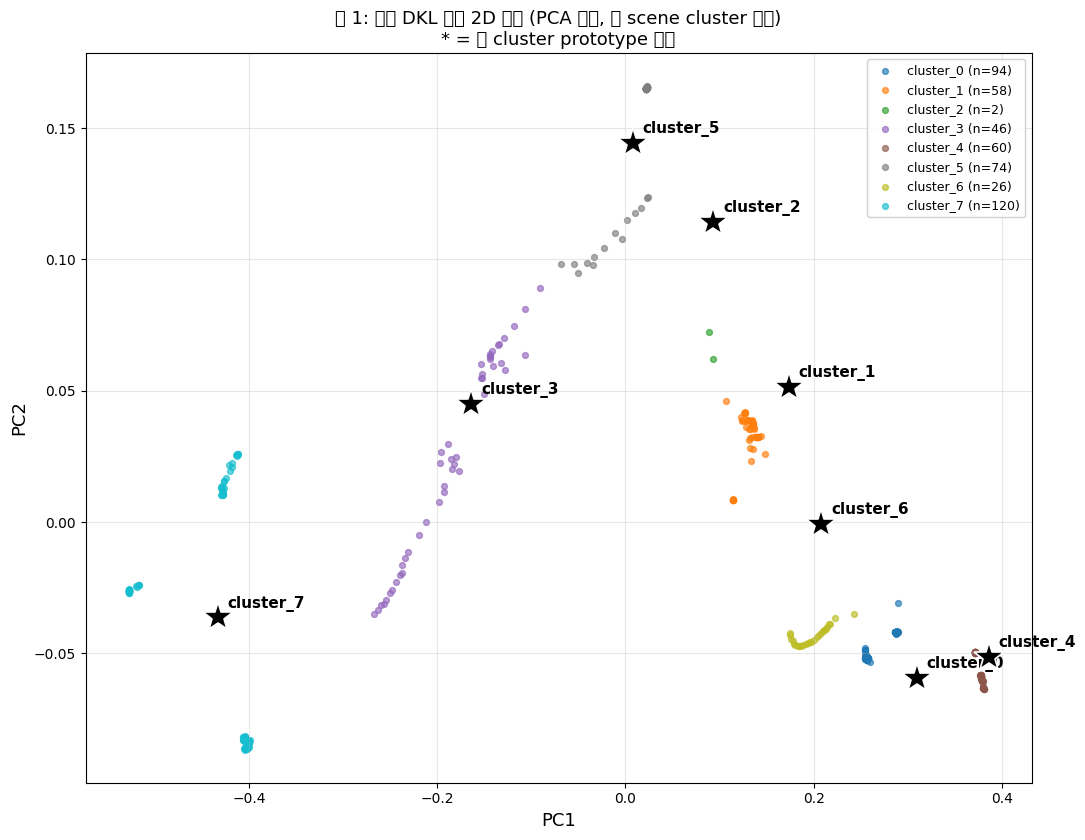

In [5]:
n_clusters = len(prototypes)
cmap = plt.get_cmap('tab10', n_clusters)
colors = [cmap(i) for i in range(n_clusters)]

fig, ax = plt.subplots(figsize=(11, 8.5))

# 散点按 cluster 着色
for c in range(n_clusters):
    mask = image_clusters == c
    if mask.sum() == 0:
        continue
    ax.scatter(proj[mask, 0], proj[mask, 1],
               s=18, alpha=0.65, color=colors[c],
               label=f"{prototypes[c].name} (n={int(mask.sum())})")

# prototype 中心（大 X 标记 + 标注）
for i in range(n_clusters):
    ax.plot(proto_proj[i, 0], proto_proj[i, 1],
            marker='*', markersize=22, color='black',
            markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    ax.annotate(prototypes[i].name, (proto_proj[i, 0], proto_proj[i, 1]),
                xytext=(7, 7), textcoords='offset points',
                fontsize=11, fontweight='bold', color='black')

ax.set_xlabel("PC1", fontsize=13)
ax.set_ylabel("PC2", fontsize=13)
ax.set_title("图 1: 图像 DKL 特征 2D 分布 (PCA 降维, 按 scene cluster 着色)\n"
             "* = 各 cluster prototype 中心", fontsize=13)
ax.legend(loc='best', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show();

## 5. 加载 8 个 cluster LUT + base LUT

In [6]:
def load_lut(path: Path) -> np.ndarray:
    """返回 [16,16,16,3] float32 [0,1] 的 LUT 数组。"""
    payload = torch.load(path, map_location="cpu")
    lut = payload.get("lut") if isinstance(payload, dict) else payload
    return lut.numpy().astype(np.float32)

lut_names = ["base"] + [f"cluster_{i}" for i in range(n_clusters)]
lut_paths = [BASE_LUT] + [LUT_DIR / f"cluster_{i}_lut.pt" for i in range(n_clusters)]

luts = {}
for name, path in zip(lut_names, lut_paths):
    if path.exists():
        luts[name] = load_lut(path)
        print(f"  已加载 {name}: {path.name}  shape={luts[name].shape}")
    else:
        print(f"  [缺失] {name}: {path}")

print(f"\n共加载 {len(luts)} 个 LUT")

  已加载 base: base_lut.pt  shape=(16, 16, 16, 3)
  已加载 cluster_0: cluster_0_lut.pt  shape=(16, 16, 16, 3)
  已加载 cluster_1: cluster_1_lut.pt  shape=(16, 16, 16, 3)
  已加载 cluster_2: cluster_2_lut.pt  shape=(16, 16, 16, 3)
  已加载 cluster_3: cluster_3_lut.pt  shape=(16, 16, 16, 3)
  已加载 cluster_4: cluster_4_lut.pt  shape=(16, 16, 16, 3)
  已加载 cluster_5: cluster_5_lut.pt  shape=(16, 16, 16, 3)
  已加载 cluster_6: cluster_6_lut.pt  shape=(16, 16, 16, 3)
  已加载 cluster_7: cluster_7_lut.pt  shape=(16, 16, 16, 3)

共加载 9 个 LUT


## 6. 构造 8×8×8 下采样 RGB 色卡

取 `N=8`，共 `8³ = 512` 个颜色点。将 512 个颜色块排成 `16` 列 × `32` 行的网格（每块 `8×8` 像素），形成 `64×128` 色卡图。

In [7]:
N = 8                      # 每通道采样数 → 512 色
BLOCK = 8                  # 每个色块的像素边长
COLS = 16                  # 色卡列数

# 生成 512 个 RGB 网格点 [0,1]
axis = np.linspace(0, 1, N)
grid = np.stack(np.meshgrid(axis, axis, axis, indexing="ij"), axis=-1).reshape(-1, 3)

# 对每个 LUT 构建 RegularGridInterpolator
interps = {}
grid_coords = [np.linspace(0, 1, 16)] * 3
for name, lut in luts.items():
    interps[name] = RegularGridInterpolator(grid_coords, lut, bounds_error=False, fill_value=None)

# 应用每个 LUT，得到优化后的 512 色
opt_colors = {name: np.clip(interp(grid), 0, 1) for name, interp in interps.items()}

# 将 512 个颜色排成色卡图 [H, W, 3]
def build_swatch(colors: np.ndarray) -> np.ndarray:
    rows = int(np.ceil(512 / COLS))
    canvas = np.zeros((rows * BLOCK, COLS * BLOCK, 3), dtype=np.float32)
    for i in range(min(512, len(colors))):
        r, c = divmod(i, COLS)
        canvas[r*BLOCK:(r+1)*BLOCK, c*BLOCK:(c+1)*BLOCK] = colors[i]
    return canvas

orig_swatch = build_swatch(grid)
opt_swatches = {name: build_swatch(opt_colors[name]) for name in luts}

print(f"色卡尺寸: {orig_swatch.shape[0]}x{orig_swatch.shape[1]} px")
print(f"颜色点数: {len(grid)}")

色卡尺寸: 256x128 px
颜色点数: 512


## 7. 图 2a：原始色卡与各 LUT 优化后色卡并排对比

C:\Users\16978\AppData\Local\Temp\ipykernel_29172\1098334372.py:26: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\1098334372.py:26: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\1098334372.py:26: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\1098334372.py:26: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\1098334372.py:26: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.

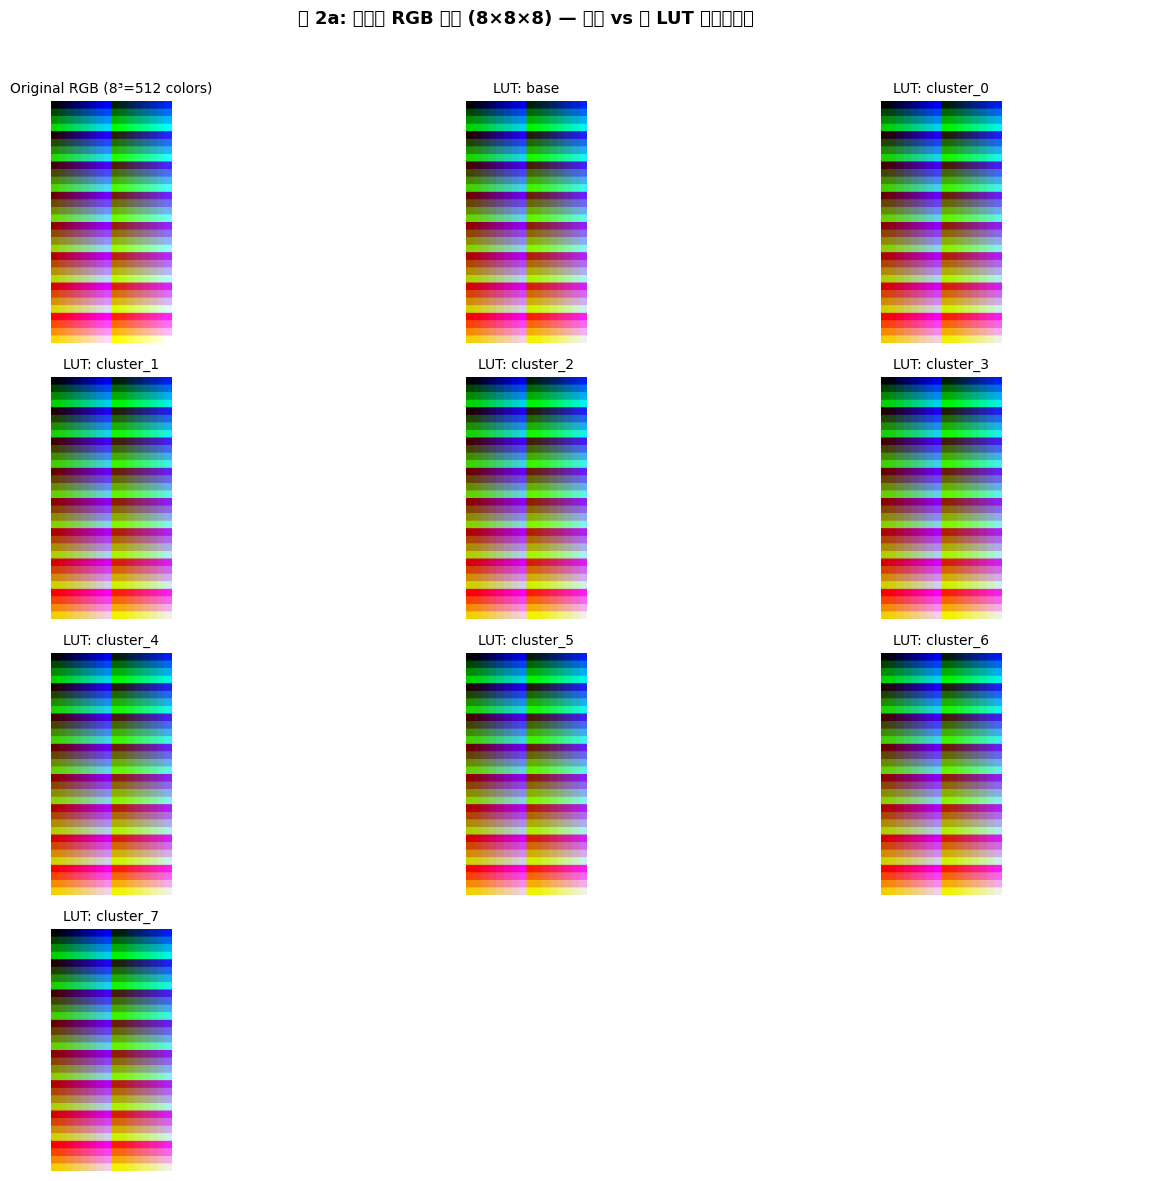

In [8]:
n_luts = len(luts)
ncols = 3
nrows = int(np.ceil((n_luts + 1) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows))
axes = np.atleast_1d(axes).ravel()

# 第 1 个 = 原始色卡
axes[0].imshow(orig_swatch)
axes[0].set_title("Original RGB (8³=512 colors)", fontsize=10)
axes[0].axis("off")

# 其余 = 各 LUT 优化后
for i, (name, swatch) in enumerate(opt_swatches.items(), start=1):
    ax = axes[i]
    ax.imshow(swatch)
    ax.set_title(f"LUT: {name}", fontsize=10)
    ax.axis("off")

# 隐藏多余子图
for ax in axes[len(luts)+1:]:
    ax.axis("off")

fig.suptitle("图 2a: 下采样 RGB 色卡 (8×8×8) — 原始 vs 各 LUT 优化后颜色",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show();

## 8. 图 2b：每个 LUT 的颜色偏移量（优化 − 原始）热力图

用向量差模长 ‖ΔRGB‖ 表示每个颜色点被 LUT 改变的程度，用颜色编码偏移量，显著位置显示为红色调（偏移大）、深色调（偏移小）。

C:\Users\16978\AppData\Local\Temp\ipykernel_29172\4011601817.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\4011601817.py:29: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\4011601817.py:29: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\4011601817.py:29: UserWarning: Glyph 39068 (\N{CJK UNIFIED IDEOGRAPH-989C}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\16978\AppData\Local\Temp\ipykernel_29172\4011601817.py:29: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.tight_lay

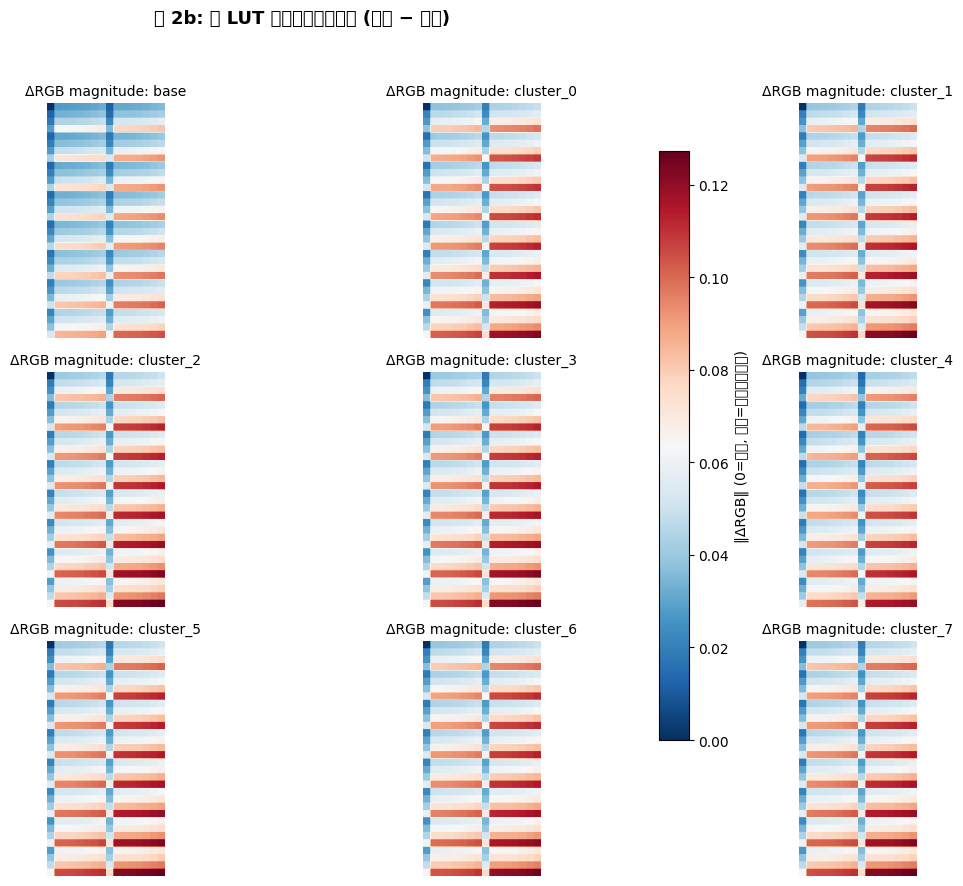

In [9]:
n_luts = len(luts)
ncols = 3
nrows = int(np.ceil(n_luts / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows))
axes = np.atleast_1d(axes).ravel()

global_max = 0.0
for name, swatch in opt_swatches.items():
    delta = swatch - orig_swatch
    mag = np.linalg.norm(delta, axis=-1)
    global_max = max(global_max, float(mag.max()))

for i, (name, swatch) in enumerate(opt_swatches.items()):
    ax = axes[i]
    delta = swatch - orig_swatch
    mag = np.linalg.norm(delta, axis=-1)
    im = ax.imshow(mag, cmap="RdBu_r", vmin=0, vmax=global_max)
    ax.set_title(f"ΔRGB magnitude: {name}", fontsize=10)
    ax.axis("off")

for ax in axes[n_luts:]:
    ax.axis("off")

fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85,
             label="‖ΔRGB‖ (0=不变, 越大=颜色改变越大)")
fig.suptitle("图 2b: 各 LUT 颜色偏移量热力图 (优化 − 原始)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show();

## 9. 图 2c：全 LUT 交互式滑杆对比（可选）

使用 ipywidgets 滑杆在 9 个 LUT 之间切换查看优化后的色卡。若未安装 ipywidgets 本单元格会跳过。

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    names = list(luts.keys())

    def update(name):
        fig2, ax2 = plt.subplots(figsize=(12, 4))
        ax2.imshow(opt_swatches[name])
        ax2.set_title(f"LUT: {name}", fontsize=12)
        ax2.axis("off")
        plt.show()

    widget = widgets.Dropdown(options=names, value=names[0], description="选择 LUT:")
    out = widgets.interactive_output(update, {"name": widget})
    display(widgets.VBox([widget, out]))
    print("ipywidgets 可用，已显示交互式对比。")
except ImportError:
    print("[skip] ipywidgets 未安装，跳过交互式对比。可运行: pip install ipywidgets")

ipywidgets 可用，已显示交互式对比。
